# Function basics

This tutorial shows how to call on mass functions and perform
basic operations with them in `imf`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import imf

## Making and calling functions

`imf` has many available IMF forms (for a full rundown,
see `imf.imf`). All of these forms are defined as `MassFunctions`, which enable many helpful operations. Let's instantiate a few so we can see them in action. We'll establish a common mass range from 0.03-120 $M_\odot$ for the sake of comparison.

In [2]:
#define mass bounds
mmin = 0.03
mmax = 120
plot_masses = np.geomspace(mmin,mmax,100)

and then call the mass functions. The `imf` module of 
`imf`, which contains all the stellar mass functions, is preloaded when you `import imf`, so defined functions can be called as follows:

In [3]:
kroupa = imf.Kroupa(mmin=mmin,mmax=mmax)
chabrier = imf.ChabrierPowerLaw(mmin=mmin,mmax=mmax)

These two are mass functions based off of the canonical 
[Kroupa](https://doi.org/10.1046/j.1365-8711.2001.04022.x) and [Chabrier](https://doi.org/10.1086/376392) forms of the IMF, i.e. they are a broken power law and a log-normal with a power law tail respectively. Since we didn’t specify any other parameter values, these functions are consistent with the canonical versions, which we can see if we plot them.

The linear form of the IMF ($dn/dm$) can be accessed by calling the function directly (alternatively, calling the `dn_dm` attribute).

In [4]:
print(kroupa(0.5), kroupa.dn_dm(0.5))

0.45033997101475043 0.45033997101475043


If we visualize these two, we get the forms we expect:

Text(0, 0.5, 'dn/dm')

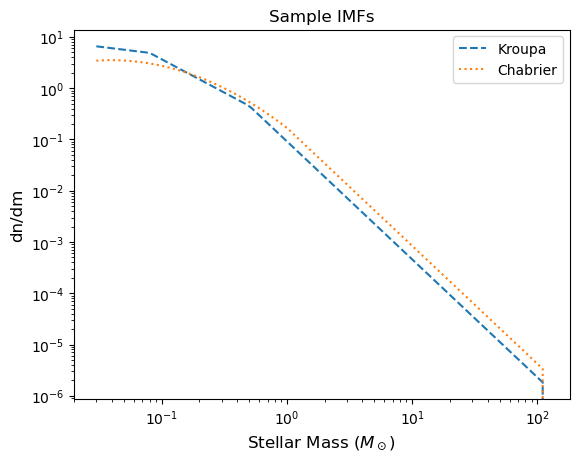

In [5]:
plt.figure()
plt.plot(plot_masses, kroupa(plot_masses), '--', label='Kroupa')
plt.plot(plot_masses, chabrier(plot_masses), ':', label='Chabrier')
plt.xscale('log')
plt.yscale('log')

plt.legend(loc='best')
plt.title('Sample IMFs', fontsize='large')
plt.xlabel(r'Stellar Mass ($M_\odot$)',fontsize='large')
plt.ylabel('dn/dm',fontsize='large')

However, defined `MassFunctions` generally have parameters 
affecting the function's shape that can be tuned by the user. For example, if we wanted to make a Kroupa-esque (broken power law) IMF with a less steep high-mass slope:

In [6]:
kroupa_alt = imf.Kroupa(mmin=mmin,mmax=mmax,p3=1.5)

Text(0, 0.5, 'dn/dm')

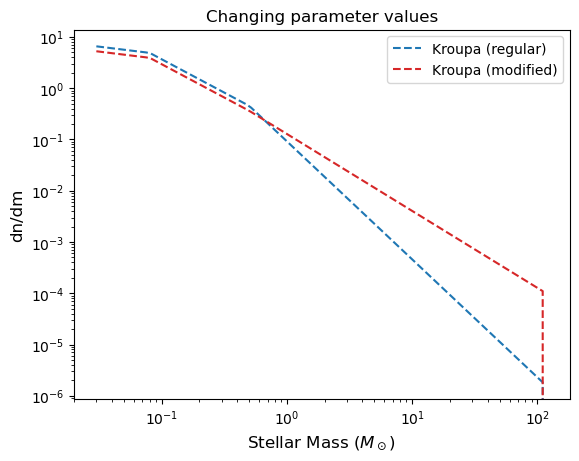

In [7]:
plt.figure()
plt.plot(plot_masses, kroupa(plot_masses), '--', label='Kroupa (regular)')
plt.plot(plot_masses, kroupa_alt(plot_masses), '--', color='tab:red',
         label='Kroupa (modified)')
plt.xscale('log')
plt.yscale('log')

plt.legend(loc='best')
plt.title('Changing parameter values', fontsize='large')
plt.xlabel(r'Stellar Mass ($M_\odot$)',fontsize='large')
plt.ylabel('dn/dm',fontsize='large')

A full accounting of tunable parameters can be found in the API.
In addition to the more generic and customizable IMF forms in the `imf` module, there are various predefined mass functions that can be called from `imf` directly. Default values for these can be found in the API, but they generally follow the corresponding canonical functions.

In [8]:
imf.salpeter, imf.kroupa, imf.chabrier, imf.chabrierlognormal, imf.chabrier2005

(<imf.imf.Salpeter at 0x153f240934d0>,
 <imf.imf.ChabrierPowerLaw at 0x153f23e6b9d0>)

Moving back to our instances: IMFs are frequently invoked in their 
log form ($dn/d \log m$). This form can be accessed by calling a function's `mass_weighted` attribute.

In [9]:
print(kroupa.mass_weighted(0.5))

0.22516998550737521


Text(0, 0.5, 'dn/d log m')

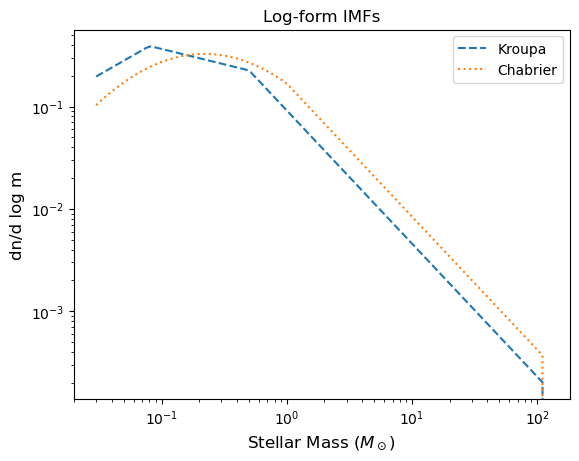

In [10]:
plt.figure()
plt.plot(plot_masses, kroupa.mass_weighted(plot_masses), '--', label='Kroupa')
plt.plot(plot_masses, chabrier.mass_weighted(plot_masses), ':', label='Chabrier')
plt.xscale('log')
plt.yscale('log')

plt.legend(loc='best')
plt.title('Log-form IMFs', fontsize='large')
plt.xlabel(r'Stellar Mass ($M_\odot$)',fontsize='large')
plt.ylabel('dn/d log m',fontsize='large')

As part of instantiation, each `MassFunction` calculates a
corresponding cumulative version, which can be accessed by calling either the `n_of_m` attribute or the function with the keyword `integral_form` set to `True`.

In [11]:
print(kroupa(0.5,integral_form=True), kroupa.n_of_m(0.5))

0.8269317283930467 0.8269317283930467


Text(0, 0.5, 'N(M) (normalized)')

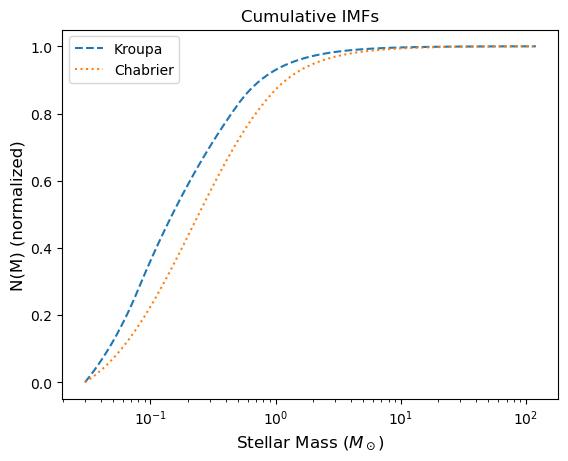

In [12]:
plt.figure()
plt.plot(plot_masses, kroupa.n_of_m(plot_masses), '--', label='Kroupa')
plt.plot(plot_masses, chabrier.n_of_m(plot_masses), ':', label='Chabrier')
plt.xscale('log')

plt.legend(loc='best')
plt.title('Cumulative IMFs', fontsize='large')
plt.xlabel(r'Stellar Mass ($M_\odot$)',fontsize='large')
plt.ylabel('N(M) (normalized)',fontsize='large')

## Operations

Now that we're familiar with how to access the mass functions, we can
introduce the other things they can do. The main set of operations available to each `MassFunction` has to to with integration of the underlying IMF. By calling the `integrate` method, we can integrate the IMF over some mass range:

In [13]:
print(kroupa.integrate(0.2,20))

(np.float64(0.4092417799541118), 0)


`integrate` returns the integral along with the error, formatted
akin to the output of `scipy`'s [integrate.quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html), which handles most integration in the package (though not all). Likewise, if we call `m_integrate` we can integrate the mass-weighted version:

In [14]:
print(kroupa.m_integrate(0.2,20))

(np.float64(0.32733923321851244), 0)


For the sake of comparison, let's see the fraction of mass contained in
low-mass ($<1 \, M_\odot$) stars according to each IMF form.

In [15]:
print(f'Kroupa low-mass fraction: {kroupa.m_integrate(mmin,1)[0] / kroupa.m_integrate(mmin,mmax)[0]}')
print(f'Chabrier low-mass fraction: {chabrier.m_integrate(mmin,1)[0] / chabrier.m_integrate(mmin,mmax)[0]}')

Kroupa low-mass fraction: 0.46458612705588004
Chabrier low-mass fraction: 0.3630117729938909


These match up pretty well with our log-form plot from earlier. All IMFs
can also be normalized (i.e. integral set to 1) over a provided mass range; if no bounds are provided, the function's mass bounds are used. Many forms come normalized over the entire range by default.

In [16]:
print(f'Integral over whole domain: {kroupa.integrate(mmin,mmax)[0]}')
kroupa.normalize(0.2,20)
print(f'Integral over whole domain (normalized to part of domain): {kroupa.integrate(mmin,mmax)[0]}')
kroupa.normalize()
print(f'Integral over whole domain, renormalized: {kroupa.integrate(mmin,mmax)[0]}')

Integral over whole domain: 1.0
Integral over whole domain (normalized to part of domain): 2.4435432768182412
Integral over whole domain, renormalized: 1.0


Finally, if you want to calculate an IMF-weighted average of some
function which depends on stellar mass, you can use the `weight_average` method, which for a function $f(m)$ is equivalent to:

$$
\begin{equation}
\frac{\int_{\rm imf \, min}^{\rm imf \, max}f(m)\psi(m)dm}{\int_{\rm imf \, min}^{\rm imf \, max}\psi(m)dm}
\end{equation}
$$

Any arguments for the function should be provided to `weight_average`.

In [17]:
def func_of_m(m):
    return m**3

def func_with_args(m, a, b):
    return a * m**3 + b

print(kroupa.weight_average(func_of_m))
print(kroupa.weight_average(func_with_args, 2, -10))

184.21126936228038
358.4225390489498


Even if we normalize the IMF differently, the weighted average is stable,
as expected.

In [18]:
kroupa.normalize(0.2,20)
print(kroupa.weight_average(func_of_m))

184.21126936228043
